# **IBM HR Employee Attrition Analysis**

Author: Samruddhi Bhandari | Tools: Python, Pandas, NumPy, Matplotlib, Seaborn

---

## Project Overview

This project analyzes IBM's HR dataset of 1,470 employees across 35 features to uncover the root causes of employee attrition. The analysis identifies which employee segments are most at risk, quantifies the compensation and satisfaction gap between leavers and stayers, and delivers actionable retention recommendations for the HR Director.

## Business Problem

IBM's HR team lacks clarity on why employees leave. Without understanding the key attrition drivers, retention programs are generic, costly, and ineffective. This project answers: *Which employees are most likely to leave IBM, and what organizational factors are pushing them out?*

## Aim

To analyze IBM's HR employee data and identify the strongest predictors of attrition — including compensation gaps, overtime patterns, satisfaction scores, and career growth stagnation — so the HR team can prioritize high-impact retention interventions.

---

## Key Performance Indicators (KPIs)

1.Overall Attrition Rate

2.Attrition by Department & Job Role

3.Tenure of Attrited vs Retained Employees

4.Compensation Gap Index

5.Overtime & Work-Life Balance Impact

6.Employee Satisfaction Risk Score


## Data Dictionary

| Total Columns | Total Rows | Source |
|---|---|---|
| 35 | 1,470 | IBM HR Analytics Dataset(Kaggle) |

| # | Column | Type | Description | Example |
|---|--------|------|-------------|---------|
| 1 | Age | Integer | Employee age in years | 35 |
| 2 | Attrition | Binary | Whether the employee left IBM — encoded as 1 (Yes) or 0 (No) | 1, 0 |
| 3 | BusinessTravel | Category | Frequency of work-related travel | "Travel_Rarely", "Travel_Frequently" |
| 4 | DailyRate | Integer | Daily pay rate in USD | 802 |
| 5 | Department | Category | Department the employee belongs to | "Sales", "Research & Development" |
| 6 | DistanceFromHome | Integer | Distance from home to office in km | 1, 29 |
| 7 | Education | Ordinal | Education level (1=Below College → 5=Doctor) | 1–5 |
| 8 | EducationField | Category | Field of study | "Life Sciences", "Technical Degree" |
| 9 | EmployeeNumber | Integer | Unique employee ID — not used in analysis | 1, 2, 3 |
| 10 | EnvironmentSatisfaction | Ordinal | Satisfaction with workplace environment (1=Low → 4=Very High) | 1–4 |
| 11 | Gender | Category | Employee gender | "Male", "Female" |
| 12 | HourlyRate | Integer | Hourly pay rate in USD | 94 |
| 13 | JobInvolvement | Ordinal | Level of job involvement (1=Low → 4=Very High) | 1–4 |
| 14 | JobLevel | Ordinal | Seniority level within company (1=Junior → 5=Executive) | 1–5 |
| 15 | JobRole | Category | Specific job title | "Sales Executive", "Research Scientist" |
| 16 | JobSatisfaction | Ordinal | Satisfaction with the job itself (1=Low → 4=Very High) | 1–4 |
| 17 | MaritalStatus | Category | Marital status of employee | "Single", "Married", "Divorced" |
| 18 | MonthlyIncome | Integer | Monthly salary in USD | 5993 |
| 19 | MonthlyRate | Integer | Monthly pay rate — different from take-home salary | 19479 |
| 20 | NumCompaniesWorked | Integer | Number of companies employee has worked at before IBM | 0–9 |
| 21 | OverTime | Binary | Whether employee works overtime | "Yes", "No" |
| 22 | PercentSalaryHike | Integer | Percentage salary increase at last appraisal | 11–25% |
| 23 | PerformanceRating | Ordinal | Last performance review rating (1=Low → 4=Outstanding) | 3, 4 |
| 24 | RelationshipSatisfaction | Ordinal | Satisfaction with workplace relationships (1=Low → 4=Very High) | 1–4 |
| 25 | StockOptionLevel | Ordinal | Stock option grant level (0=None → 3=High) | 0–3 |
| 26 | TotalWorkingYears | Integer | Total years of professional experience | 0–40 |
| 27 | TrainingTimesLastYear | Integer | Number of training sessions attended last year | 0–6 |
| 28 | WorkLifeBalance | Ordinal | Self-rated work-life balance (1=Bad → 4=Best) | 1–4 |
| 29 | YearsAtCompany | Integer | Number of years at IBM | 0–40 |
| 30 | YearsInCurrentRole | Integer | Years in current job role at IBM | 0–18 |
| 31 | YearsSinceLastPromotion | Integer | Years since last promotion | 0–15 |
| 32 | YearsWithCurrManager | Integer | Years working under current manager | 0–17 |
| 33 | EmployeeCount | Integer | Constant = 1 for all rows — dropped in cleaning | 1 |
| 34 | StandardHours | Integer | Constant = 80 for all rows — dropped in cleaning | 80 |
| 35 | Over18 | Category | Constant = "Y" for all rows — dropped in cleaning | "Y" |

---

## Dataset Summary

| Attribute | Value |
|-----------|-------|
| Total employees | 1,470 |
| Total features | 35 (32 used after dropping 3 constants) |
| Data collection | IBM synthetic HR dataset |
| Departments | 3 (Sales, R&D, Human Resources) |
| Unique job roles | 9 |
| Employees who left | 237 (16.1%) |
| Employees who stayed | 1,233 (83.9%) |
| Overtime employees | ~ 416 (~28%) |
| Satisfaction columns | 4 (Job, Environment, Relationship, WorkLifeBalance) |
| Constant columns dropped | 3 (EmployeeCount, StandardHours, Over18) |


##  Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('Dataset.csv')

In [4]:
pd.set_option('display.max_columns', 35)
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [5]:
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

In [6]:
df.shape

(1470, 35)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   int64 
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [8]:
df.describe()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,0.161224,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,0.367863,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,0.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,0.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,0.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,0.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [9]:
df.describe(include='object')

,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470
unique,3,3,6,2,9,3,1,2
top,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1043,961,606,882,326,673,1470,1054


## Data Cleaning
### Conclusion
- The dataset contains 1,470 employee records with no missing values and no duplicate records, indicating high data quality.
- Three constant columns (EmployeeCount, StandardHours, and Over18) were removed, reducing the dataset from 35 to 32 features.
- All categorical variables were validated, and no inconsistent or unexpected categories were found.
- Although Monthly Income contains a few outliers according to the boxplot.

In [10]:
# Null check
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [11]:
# Duplicate check
df.duplicated().sum()

np.int64(0)

In [12]:
# Checking columns that have only one value
constant_cols = ['EmployeeCount', 'StandardHours', 'Over18']

for col in constant_cols:
    print(col, ":", df[col].unique())

# Removing these columns from the dataset
df = df.drop(columns=constant_cols)

print("New dataset shape:", df.shape)

EmployeeCount : [1]
StandardHours : [80]
Over18 : ['Y']
New dataset shape: (1470, 32)


In [13]:
# Unique values in categorical columns
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}: {df[col].unique()}")


BusinessTravel: ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']

Department: ['Sales' 'Research & Development' 'Human Resources']

EducationField: ['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']

Gender: ['Female' 'Male']

JobRole: ['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Director' 'Human Resources']

MaritalStatus: ['Single' 'Married' 'Divorced']

OverTime: ['Yes' 'No']


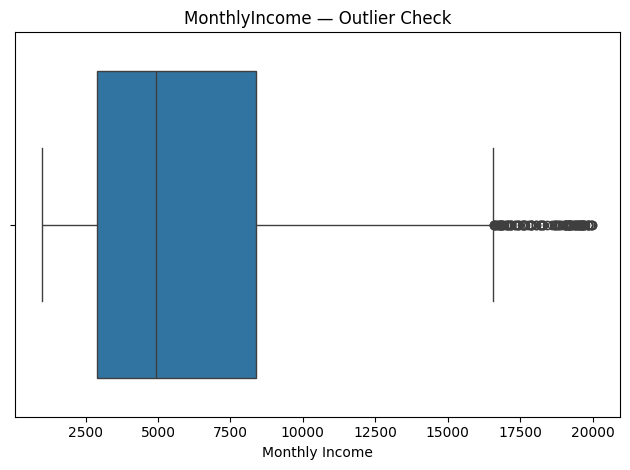

In [14]:
# Outlier check — MonthlyIncome boxplot
sns.boxplot(x=df['MonthlyIncome'])
plt.title('MonthlyIncome — Outlier Check')
plt.xlabel('Monthly Income')
plt.tight_layout()

# Statistical Baseline
- ### Conclusion
- Skewness analysis showed that 5 of the 7 key numerical features are right-skewed, with Years Since Last Promotion (1.984) and Years at Company (1.765) showing the highest skewness.
- Correlation analysis found only weak relationships with attrition. Total Working Years (0.171), Job Level (0.169), and Monthly Income (0.160) were the most influential numerical features.
- Overall, the statistical baseline suggests that employee attrition is driven by multiple factors rather than a single variable, making further exploratory analysis essential.

In [15]:
# SKEWNESS CHECK ON KEY NUMERIC COLUMNS

In [16]:
# Skewness Interpretation:
# If skewness > 1  → Right Skewed
# If skewness < -1 → Left Skewed
# If skewness is between -1 and 1 → Approximately Normal Distribution

In [17]:
# MonthlyIncome
print("MonthlyIncome Skewness:", round(df["MonthlyIncome"].skew(), 3))

MonthlyIncome Skewness: 1.37


In [18]:
# Age
print("Age Skewness:",round( df["Age"].skew(),3))

Age Skewness: 0.413


In [19]:
# YearsAtCompany
print("YearsAtCompany Skewness:", round(df["YearsAtCompany"].skew(),3))

YearsAtCompany Skewness: 1.765


In [20]:
# YearsSinceLastPromotion
print("YearsSinceLastPromotion Skewness:", round(df["YearsSinceLastPromotion"].skew(),3))

YearsSinceLastPromotion Skewness: 1.984


In [21]:
# DistanceFromHome
print("DistanceFromHome Skewness:", round(df["DistanceFromHome"].skew(),3))

DistanceFromHome Skewness: 0.958


In [22]:
# TotalWorkingYears
print("TotalWorkingYears Skewness:", round(df["TotalWorkingYears"].skew(),3))

TotalWorkingYears Skewness: 1.117


In [23]:
# NumCompaniesWorked
print("NumCompaniesWorked Skewness:", round(df["NumCompaniesWorked"].skew(),3))

NumCompaniesWorked Skewness: 1.026


In [24]:
skew_cols = [
    'MonthlyIncome',
    'Age',
    'YearsAtCompany',
    'YearsSinceLastPromotion',
    'DistanceFromHome',
    'TotalWorkingYears',
    'NumCompaniesWorked'
]

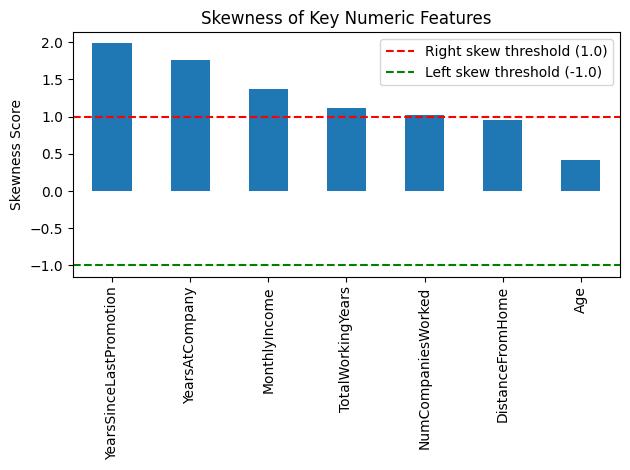

In [25]:
skew_values = df[skew_cols].skew().sort_values(ascending=False)
skew_values.plot(kind='bar')
plt.axhline(y=1, color='red', linestyle='--', label='Right skew threshold (1.0)')
plt.axhline(y=-1, color='green', linestyle='--', label='Left skew threshold (-1.0)')
plt.title('Skewness of Key Numeric Features')
plt.ylabel('Skewness Score')
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
# Correlation Interpretation:
# 0.00 - 0.10 : Negligible Correlation
# 0.10 - 0.30 : Weak Correlation
# 0.30 - 0.50 : Moderate Correlation
# Above 0.50 : Strong Correlation

In [27]:
# Finding features most related to Attrition

corr = df.corr(numeric_only=True)["Attrition"]

print("Top Features Correlated with Attrition")
print(corr.sort_values(ascending=False).head(15))

Top Features Correlated with Attrition
Attrition                   1.000000
DistanceFromHome            0.077924
NumCompaniesWorked          0.043494
MonthlyRate                 0.015170
PerformanceRating           0.002889
HourlyRate                 -0.006846
EmployeeNumber             -0.010577
PercentSalaryHike          -0.013478
Education                  -0.031373
YearsSinceLastPromotion    -0.033019
RelationshipSatisfaction   -0.045872
DailyRate                  -0.056652
TrainingTimesLastYear      -0.059478
WorkLifeBalance            -0.063939
EnvironmentSatisfaction    -0.103369
Name: Attrition, dtype: float64


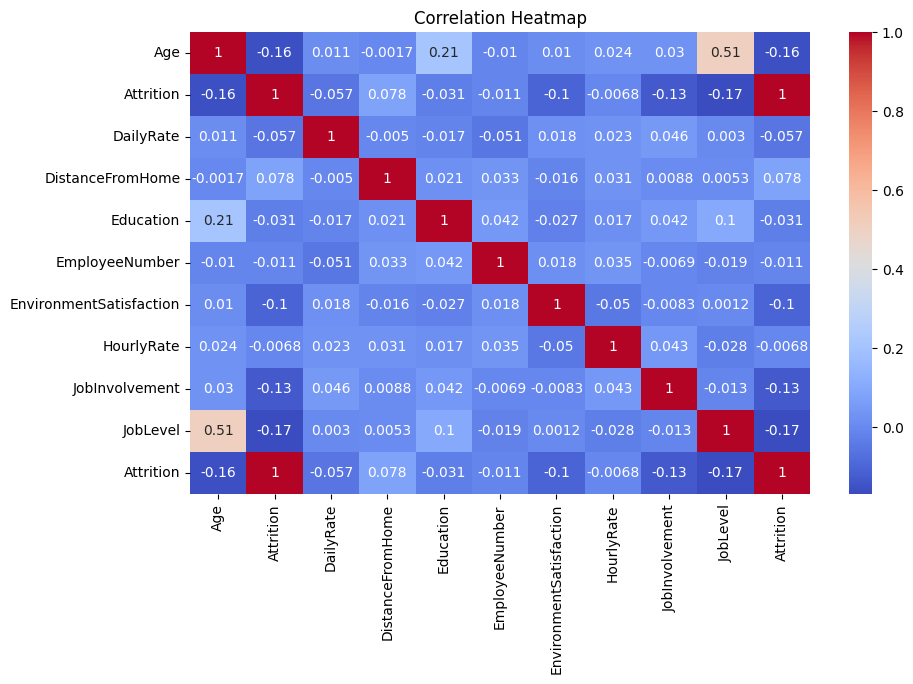

In [28]:
# Selecting top 10 features correlated with Attrition

top_features = corr.head(10).index.tolist()
top_features.append('Attrition')

# Creating correlation matrix
corr_matrix = df[top_features].corr()

# Plotting heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

# Exploratory Data Analysis

## 1. Overall Attrition Rate
**Business Question:** What percentage of IBM's 1,470 employees left?  
**Why it matters:** This is the north-star metric. All other KPIs are explained relative to this baseline.
- ### Conclusion
- The overall attrition rate is 16.1%, with 237 out of 1,470 employees leaving the company, while 1,233 employees were retained.
- The pie chart shows that most employees (83.9%) stayed with the organization, indicating that attrition affects a relatively smaller portion of the workforce.
- This 16.1% attrition rate serves as the baseline for the entire analysis. Any department, job role, or employee group with an attrition rate above 16.1% can be considered a higher-risk segment.
- The next analyses focus on identifying which employee groups contribute most to this 16.1% attrition rate and the factors driving employees to leave.

In [29]:
# Overall Attrition Rate

left_count = df['Attrition'].sum()
stayed_count = len(df) - left_count
total_employees = len(df)

attrition_rate = (left_count / total_employees) * 100

print("Attrition Rate:", round(attrition_rate, 2), "%")
print("Employees Left:", left_count)
print("Employees Stayed:", total_employees - left_count)
print("Total Employees:", total_employees)

Attrition Rate: 16.12 %
Employees Left: 237
Employees Stayed: 1233
Total Employees: 1470


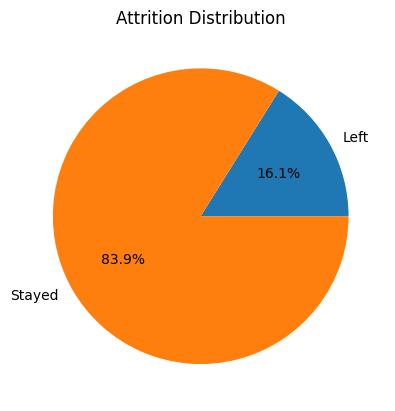

In [30]:
# Pie Chart

plt.pie([left_count, stayed_count],
        labels=['Left', 'Stayed'],
        autopct='%1.1f%%')

plt.title("Attrition Distribution")
plt.show()

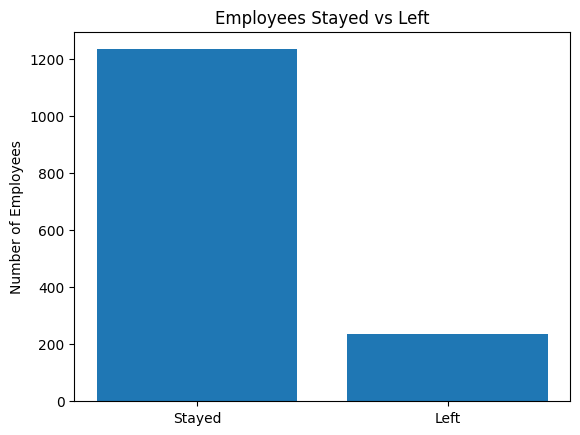

In [31]:
# Bar Chart

plt.bar(['Stayed', 'Left'],
        [stayed_count, left_count])

plt.title("Employees Stayed vs Left")
plt.ylabel("Number of Employees")
plt.show()

## 2.  Attrition by Department & Job Role
**Business Question:** Which teams are bleeding talent the most?  
**Why it matters:** Targeted retention programs need to know WHERE the problem is concentrated.
### Conclusion
- The Sales department recorded the highest attrition rate at 20.6%, followed by Human Resources at 19.0%, both exceeding the company average of 16.1%. In contrast, Research & Development reported the lowest attrition rate at 13.8%.
- At the job role level, Sales Representatives experienced the highest attrition rate at 39.8%, followed by Laboratory Technicians (23.9%) and Human Resources (23.1%), making them the most vulnerable roles.
- The findings indicate that employee attrition is concentrated in specific departments and job roles rather than being evenly distributed across the organization.
- These insights suggest that retention strategies should prioritize high-risk departments and job roles, particularly Sales Representatives and Laboratory Technicians, to reduce overall employee turnover.

In [32]:
# Department-level attrition
dept_attrition = df.groupby('Department')['Attrition'].agg(['sum','count']).reset_index()
dept_attrition.columns = ['Department', 'Left', 'Total']
dept_attrition['Attrition_Rate'] = (dept_attrition['Left'] / dept_attrition['Total']) * 100
dept_attrition = dept_attrition.sort_values('Attrition_Rate', ascending=False)
print(dept_attrition.round(2))

               Department  Left  Total  Attrition_Rate
2                   Sales    92    446           20.63
0         Human Resources    12     63           19.05
1  Research & Development   133    961           13.84


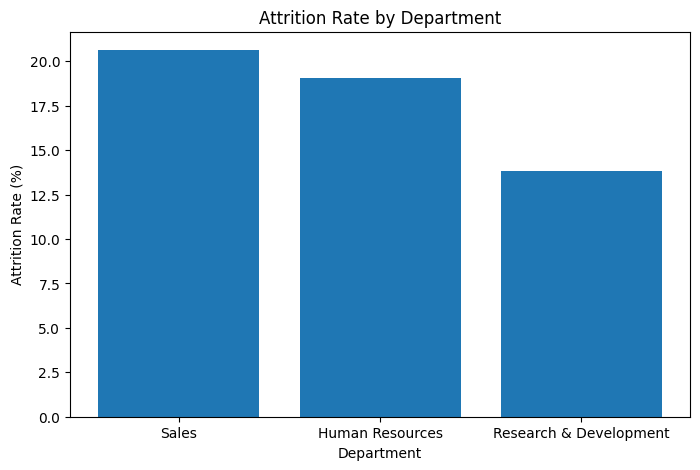

In [33]:
# Attrition Rate by Department

plt.figure(figsize=(8,5))

plt.bar(dept_attrition['Department'],
        dept_attrition['Attrition_Rate'])

plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")

plt.show()

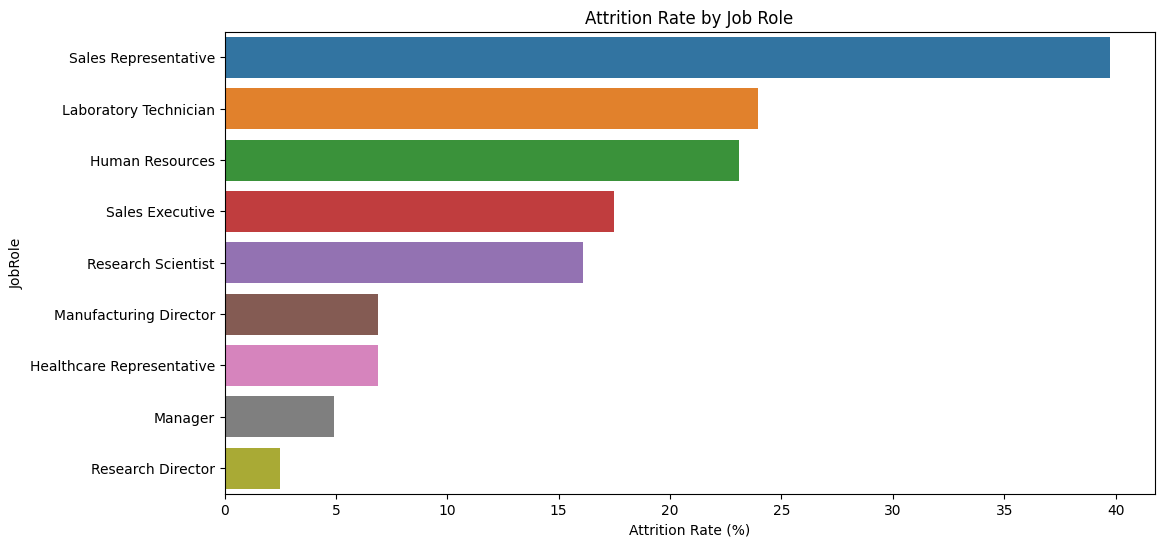

In [34]:
# Job Role Attrition Rate
jobrole_attrition = df.groupby('JobRole')['Attrition'].mean().reset_index()
jobrole_attrition['Attrition'] = jobrole_attrition['Attrition'] * 100
jobrole_attrition = jobrole_attrition.sort_values('Attrition', ascending=False)

plt.figure(figsize=(12,6))

sns.barplot(data=jobrole_attrition,
            x='Attrition',
            y='JobRole',
            hue='JobRole',
            legend=False)

plt.title("Attrition Rate by Job Role")
plt.xlabel("Attrition Rate (%)")

plt.show()

## 3. Tenure of Attrited vs Retained Employees
**Business Question:** Do employees leave early in their career or after years of service?  
**Why it matters:** Knowing WHEN people leave tells HR where to intervene — onboarding vs mid-career.
### Conclusion
- Employees who left had a much shorter median tenure (3 years) than those who stayed (6 years), indicating that attrition occurs earlier in an employee's journey.
- The 0–2 year group recorded the highest attrition rate at 29.8%, making the first two years the most critical retention window.
- Attrition declines as tenure increases, suggesting that employees become more likely to stay once they remain with the company for several years.
- These findings highlight onboarding, early career support, and expectation-setting as key areas where HR should focus its retention efforts.

In [35]:
# Tenure comparison
tenure = df.groupby('Attrition')['YearsAtCompany'].agg(['mean','median']).reset_index()
tenure['Attrition'] = tenure['Attrition'].map({0: 'Stayed', 1: 'Left'})
tenure.columns = ['Group', 'Mean Tenure (yrs)', 'Median Tenure (yrs)']
print(tenure.round(2))

    Group  Mean Tenure (yrs)  Median Tenure (yrs)
0  Stayed               7.37                  6.0
1    Left               5.13                  3.0


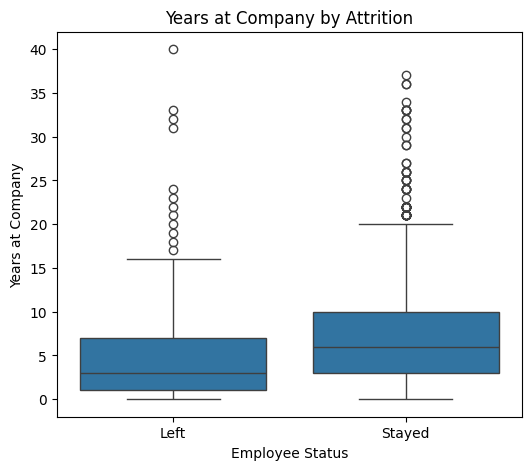

In [36]:
# Years at Company for Stayed vs Left Employees

df["Status"] = df["Attrition"].map({0: "Stayed", 1: "Left"})

plt.figure(figsize=(6,5))

sns.boxplot(data=df,
            x="Status",
            y="YearsAtCompany")

plt.title("Years at Company by Attrition")
plt.xlabel("Employee Status")
plt.ylabel("Years at Company")

plt.show()

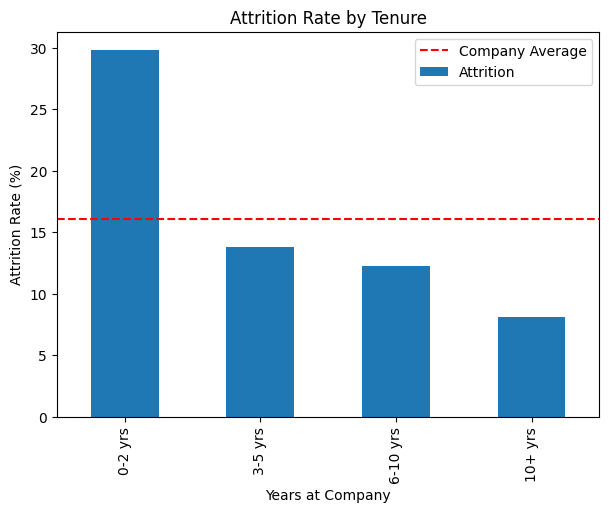

In [37]:
# Attrition Rate by Tenure
overall = df["Attrition"].mean() * 100
bins = [-1, 2, 5, 10, float("inf")]
labels = ["0-2 yrs", "3-5 yrs", "6-10 yrs", "10+ yrs"]

df["TenureBracket"] = pd.cut(df["YearsAtCompany"],bins=bins,labels=labels)
tenure_rate = df.groupby("TenureBracket", observed=False)["Attrition"].mean() * 100
plt.figure(figsize=(7,5))
tenure_rate.plot(kind="bar")
plt.axhline(overall, linestyle="--", color='red',label="Company Average")
plt.title("Attrition Rate by Tenure")
plt.xlabel("Years at Company")
plt.ylabel("Attrition Rate (%)")
plt.legend()
plt.show()

## 4. Compensation Gap Index
**Business Question:** How much less do employees who left earn compared to those who stayed?  
**Why it matters:** If the gap is significant, compensation is a lever HR can pull immediately.
### Conclusion
- Employees who left earned a median monthly income of ₹3,202, compared to ₹5,204 for employees who stayed, resulting in a salary gap of ₹2,002 per month.
- The Low income category recorded the highest attrition rate at 24.2%, well above the company average of 16.1%, while the Very High income category had the lowest attrition rate at 5.3%.
- The income distribution confirms that lower-paid employees are more likely to leave, suggesting that compensation plays an important role in employee retention.
- Employees with high salary growth potential but no recent promotion appear to be at greater risk of leaving, highlighting the need for timely salary reviews and career progression opportunities.

In [38]:
# Median is used because MonthlyIncome is right-skewed,
# so it represents the typical income better than the mean.
# Annual Income
df["IncomePerYear"] = df["MonthlyIncome"] * 12

# Median Monthly Income
left_income = df[df["Attrition"] == 1]["MonthlyIncome"].median()
stayed_income = df[df["Attrition"] == 0]["MonthlyIncome"].median()

print("Median Income of Employees who Left:", left_income)
print("Median Income of Employees who Stayed:", stayed_income)
print("Difference:", stayed_income - left_income)

Median Income of Employees who Left: 3202.0
Median Income of Employees who Stayed: 5204.0
Difference: 2002.0


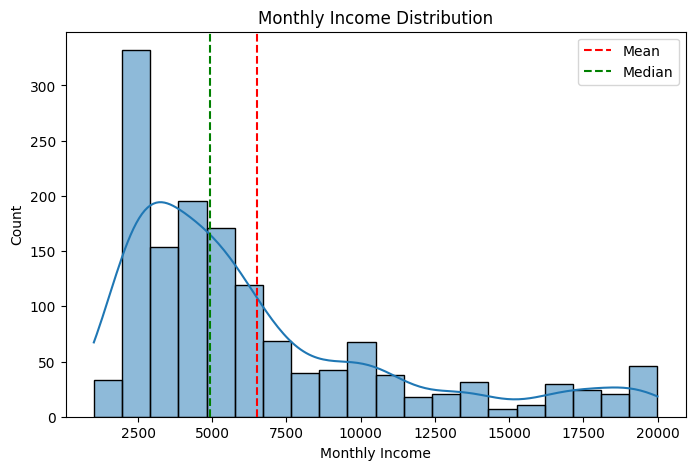

In [39]:
# Monthly Income Distribution

income_mean = df["MonthlyIncome"].mean()
income_median = df["MonthlyIncome"].median()

plt.figure(figsize=(8,5))

sns.histplot(df["MonthlyIncome"], kde=True)

plt.axvline(income_mean, color="red", linestyle="--", label="Mean")
plt.axvline(income_median, color="green", linestyle="--", label="Median")

plt.title("Monthly Income Distribution")
plt.xlabel("Monthly Income")
plt.legend()

plt.show()

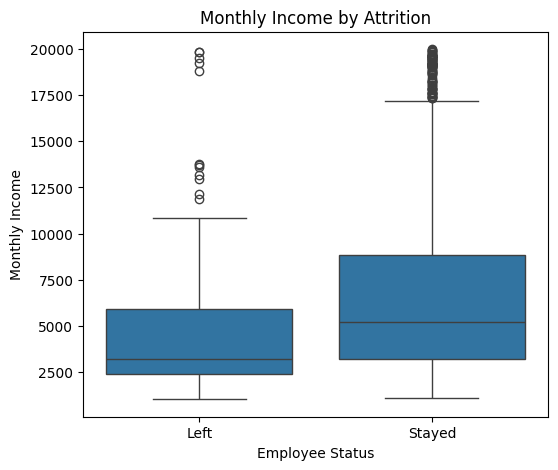

In [40]:
# Monthly Income of Stayed vs Left Employees

df["Status"] = df["Attrition"].map({0: "Stayed", 1: "Left"})

plt.figure(figsize=(6,5))

sns.boxplot(data=df,
            x="Status",
            y="MonthlyIncome")

plt.title("Monthly Income by Attrition")
plt.xlabel("Employee Status")
plt.ylabel("Monthly Income")

plt.show()

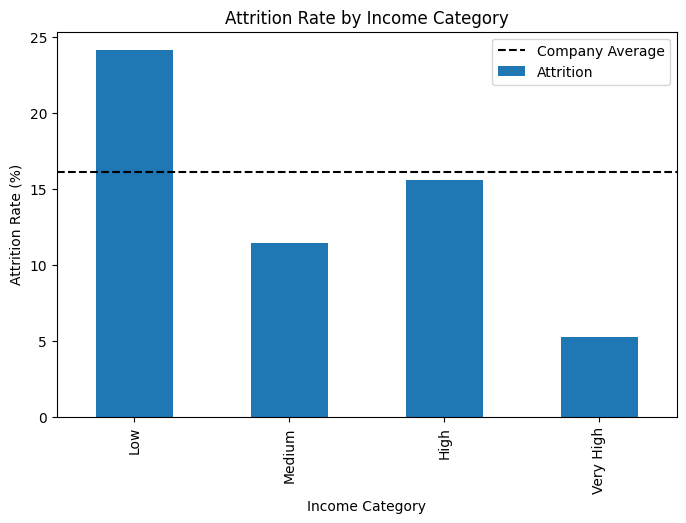

In [41]:
# Creating Income Categories

df["IncomeCategory"] = pd.cut(
    df["IncomePerYear"],
    bins=[0, 50000, 100000, 150000, 250000],
    labels=["Low", "Medium", "High", "Very High"]
)

# Attrition Rate by Income Category

income_attrition = df.groupby("IncomeCategory", observed=False)["Attrition"].mean() * 100

plt.figure(figsize=(8,5))

income_attrition.plot(kind="bar")

plt.axhline(overall, linestyle="--", color= 'black',label="Company Average")

plt.title("Attrition Rate by Income Category")
plt.xlabel("Income Category")
plt.ylabel("Attrition Rate (%)")
plt.legend()

plt.show()

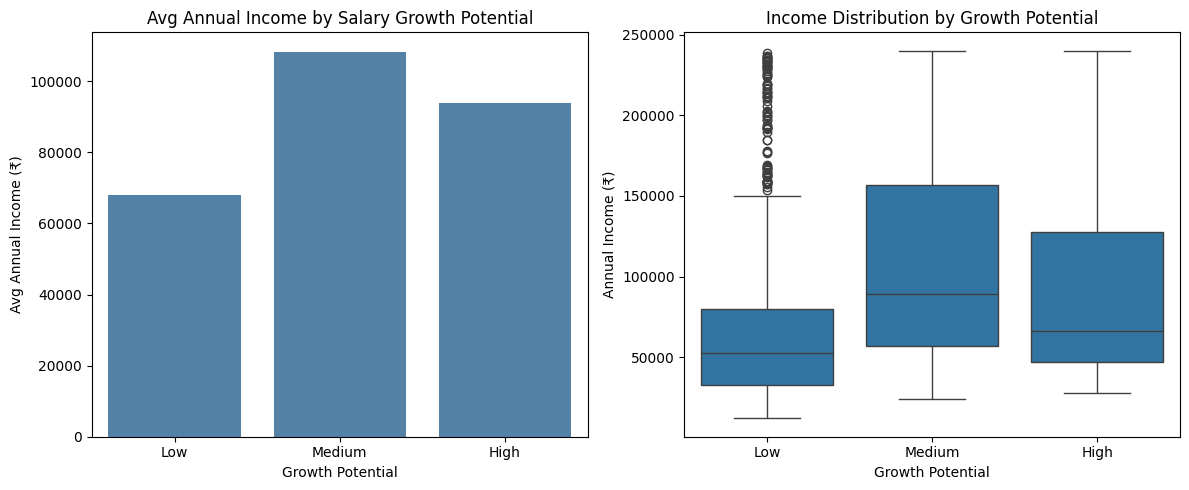

In [42]:
# Salary Growth Potential — high performer, no promotion
conditions = [
    (df['PerformanceRating'] == 4) & (df['YearsSinceLastPromotion'] >= 2),
    (df['PerformanceRating'] == 3) & (df['YearsSinceLastPromotion'] >= 3)
]
choices = ['High', 'Medium']
df['SalaryGrowthPotential'] = np.select(conditions, choices, default='Low')

sgp_result = df.groupby('SalaryGrowthPotential')['IncomePerYear'].mean().round(2).reset_index()
order = ['Low', 'Medium', 'High']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(x='SalaryGrowthPotential', y='IncomePerYear', data=sgp_result,
            order=order, ax=axes[0], color='steelblue')
axes[0].set_title('Avg Annual Income by Salary Growth Potential')
axes[0].set_xlabel('Growth Potential')
axes[0].set_ylabel('Avg Annual Income (₹)')

sns.boxplot(x='SalaryGrowthPotential', y='IncomePerYear', order=order,
            data=df, ax=axes[1])
axes[1].set_title('Income Distribution by Growth Potential')
axes[1].set_xlabel('Growth Potential')
axes[1].set_ylabel('Annual Income (₹)')

plt.tight_layout()
plt.show()


## 5.  Overtime & Work-Life Balance Impact
**Business Question:** Does overtime predict attrition? Does work-life balance rating matter?  
**Why it matters:** Overtime is a behavioral signal HR can monitor in real time — unlike satisfaction surveys.
### Conclusion
- Employees working overtime recorded an attrition rate of 30.5%, nearly three times higher than employees who did not work overtime (10.4%) and well above the company average of 16.1%. This indicates that overtime is the strongest behavioral indicator of employee attrition.
- Employees with the lowest Work-Life Balance rating (1) experienced the highest attrition rate at 31.2%, while employees with a rating of 3 had the lowest attrition at 14.3%. This suggests that poor work-life balance increases the likelihood of employees leaving the organization.
- Although work-life balance influences attrition, overtime has a much stronger and more consistent impact. Employees working overtime remain at high risk regardless of their work-life balance rating.
- These findings highlight workload management as a key retention strategy. Reducing excessive overtime and improving work-life balance can help HR lower attrition and improve employee well-being.

In [43]:
# Attrition Rate by Overtime

overtime_attrition = df.groupby("OverTime")["Attrition"].mean() * 100

print(overtime_attrition)

ot_yes = overtime_attrition["Yes"]
ot_no = overtime_attrition["No"]


OverTime
No     10.436433
Yes    30.528846
Name: Attrition, dtype: float64


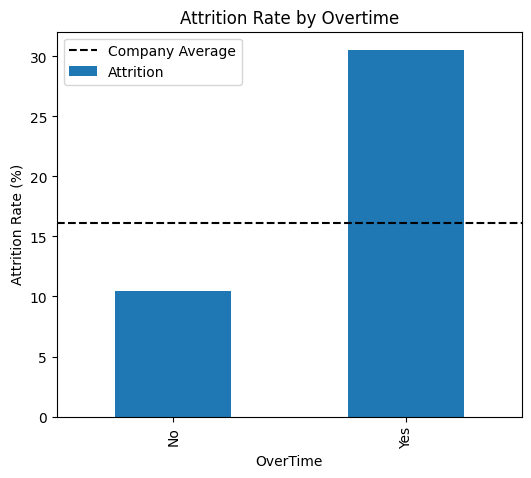

In [44]:
# Attrition Rate by Overtime

plt.figure(figsize=(6,5))

overtime_attrition.plot(kind="bar")

plt.axhline(overall, linestyle="--", color='black',label="Company Average")

plt.title("Attrition Rate by Overtime")
plt.xlabel("OverTime")
plt.ylabel("Attrition Rate (%)")
plt.legend()

plt.show()

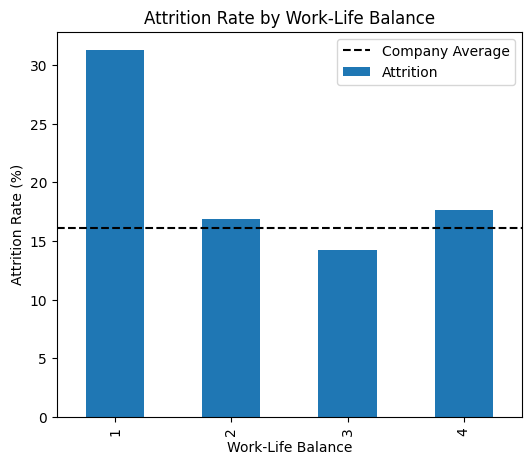

In [45]:
# Attrition Rate by Work-Life Balance

wlb = df.groupby("WorkLifeBalance")["Attrition"].mean() * 100

plt.figure(figsize=(6,5))

wlb.plot(kind="bar")

plt.axhline(overall, linestyle="--", color='black',label="Company Average")

plt.title("Attrition Rate by Work-Life Balance")
plt.xlabel("Work-Life Balance")
plt.ylabel("Attrition Rate (%)")
plt.legend()

plt.show()

In [46]:
# Overall Attrition Rate
print("Overall Attrition Rate:", round(overall, 2), "%")

print("\nDepartment")
print(df.groupby("Department")["Attrition"].mean() * 100)

print("\nOverTime")
print(df.groupby("OverTime")["Attrition"].mean() * 100)

print("\nMarital Status")
print(df.groupby("MaritalStatus")["Attrition"].mean() * 100)

print("\nJob Role")
print(df.groupby("JobRole")["Attrition"].mean() * 100)

print("\nBusiness Travel")
print(df.groupby("BusinessTravel")["Attrition"].mean() * 100)

print("\nGender")
print(df.groupby("Gender")["Attrition"].mean() * 100)

Overall Attrition Rate: 16.12 %

Department
Department
Human Resources           19.047619
Research & Development    13.839750
Sales                     20.627803
Name: Attrition, dtype: float64

OverTime
OverTime
No     10.436433
Yes    30.528846
Name: Attrition, dtype: float64

Marital Status
MaritalStatus
Divorced    10.091743
Married     12.481426
Single      25.531915
Name: Attrition, dtype: float64

Job Role
JobRole
Healthcare Representative     6.870229
Human Resources              23.076923
Laboratory Technician        23.938224
Manager                       4.901961
Manufacturing Director        6.896552
Research Director             2.500000
Research Scientist           16.095890
Sales Executive              17.484663
Sales Representative         39.759036
Name: Attrition, dtype: float64

Business Travel
BusinessTravel
Non-Travel            8.000000
Travel_Frequently    24.909747
Travel_Rarely        14.956855
Name: Attrition, dtype: float64

Gender
Gender
Female    14.795918

## Demographics & Attrition
### Conclusion
- Demographic analysis shows that employee attrition is highest among younger, single employees and those living farther from the workplace.
- Employees aged 18–25 recorded the highest attrition rate (34.8%), while single employees (25.5%) and employees living more than 15 km from work (20.7%) also exceeded the company average of 16.1%.
- Gender had only a small impact on attrition, with male employees (17.0%) showing a slightly higher attrition rate than female employees (14.8%).
- These findings suggest that retention initiatives should focus on early-career employees, provide support for single employees, and consider flexible work options for employees with longer commutes.

- ## Age

In [47]:
# Creating Age Groups
bins = [18, 25, 35, 45, 60]
labels = ["18-25", "26-35", "36-45", "46-60"]
df["AgeGroup"] = pd.cut(df["Age"], bins=bins, labels=labels)

In [48]:
# Age Statistics
print("Mean Age:", round(df["Age"].mean(), 2))
print("Median Age:", df["Age"].median())
print("Standard Deviation:", round(df["Age"].std(), 2))

Mean Age: 36.92
Median Age: 36.0
Standard Deviation: 9.14


In [49]:
# Attrition Rate by Age Group
age_attrition = df.groupby("AgeGroup", observed=False)["Attrition"].mean() * 100
print("\nAttrition Rate by Age Group")
print(age_attrition)


Attrition Rate by Age Group
AgeGroup
18-25    34.782609
26-35    19.141914
36-45     9.188034
46-60    12.454212
Name: Attrition, dtype: float64


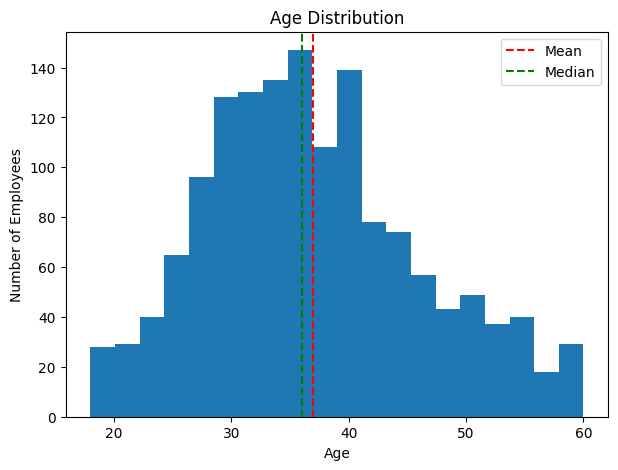

In [50]:
# Age Distribution

plt.figure(figsize=(7,5))

plt.hist(df["Age"], bins=20)

plt.axvline(df["Age"].mean(), color="red", linestyle="--", label="Mean")
plt.axvline(df["Age"].median(), color="green", linestyle="--", label="Median")

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Employees")
plt.legend()

plt.show()

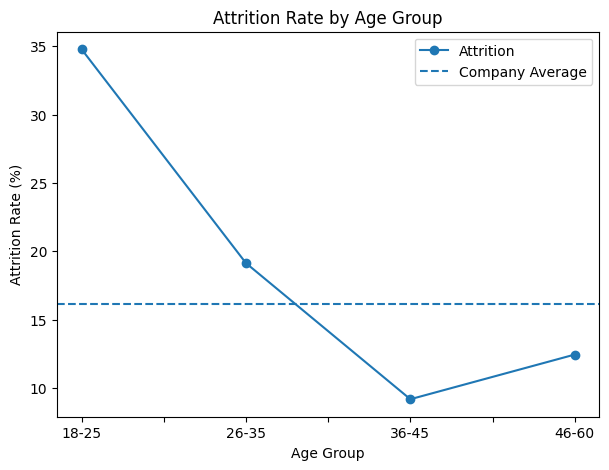

In [51]:
# Attrition Rate by Age Group

plt.figure(figsize=(7,5))

age_attrition.plot(kind="line", marker="o")

plt.axhline(overall, linestyle="--", label="Company Average")

plt.title("Attrition Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Attrition Rate (%)")
plt.legend()

plt.show()

**Age Insight:**
Employees aged 18–25 recorded the highest attrition rate (34.8%), indicating that younger employees are more likely to leave than older age groups.

- ## Gender

In [52]:
# Gender — attrition by department and gender
gender_result = df.groupby(['Department','Gender'])['Attrition'].agg(['sum','count']).reset_index()
gender_result.columns = ['Department','Gender','Left','Total']
gender_result['Attrition_Percentage'] = (gender_result['Left'] / gender_result['Total']) * 100
gender_result['Attrition_Percentage']

0    30.000000
1    13.953488
2    11.345646
3    15.463918
4    20.105820
5    21.011673
Name: Attrition_Percentage, dtype: float64

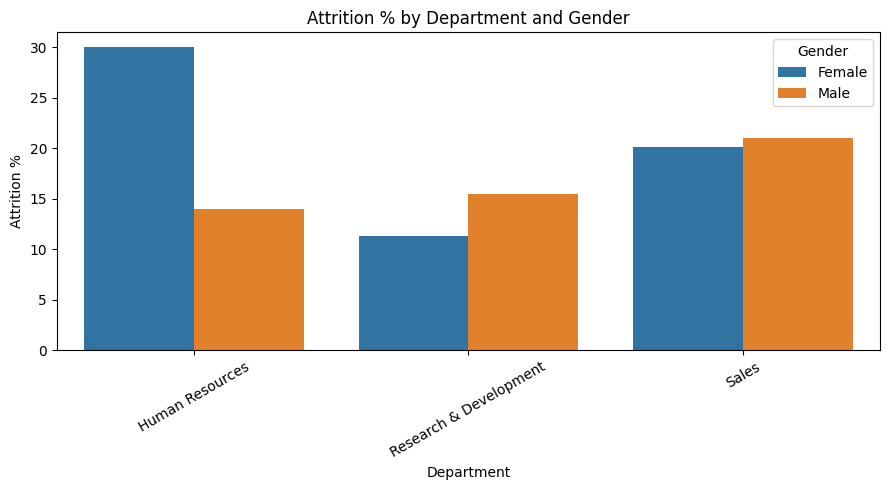

In [53]:
plt.figure(figsize=(9, 5))
sns.barplot(data=gender_result, x='Department', y='Attrition_Percentage', hue='Gender')
plt.title('Attrition % by Department and Gender')
plt.ylabel('Attrition %')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Insight:**
Male employees showed a slightly higher attrition rate (17.0%) than female employees (14.8%), suggesting gender has only a minor influence on employee turnover.

- ## Marital Status

In [54]:
# Attrition Rate by Marital Status
marital_result = df.groupby("MaritalStatus")["Attrition"].mean() * 100
marital_result

MaritalStatus
Divorced    10.091743
Married     12.481426
Single      25.531915
Name: Attrition, dtype: float64

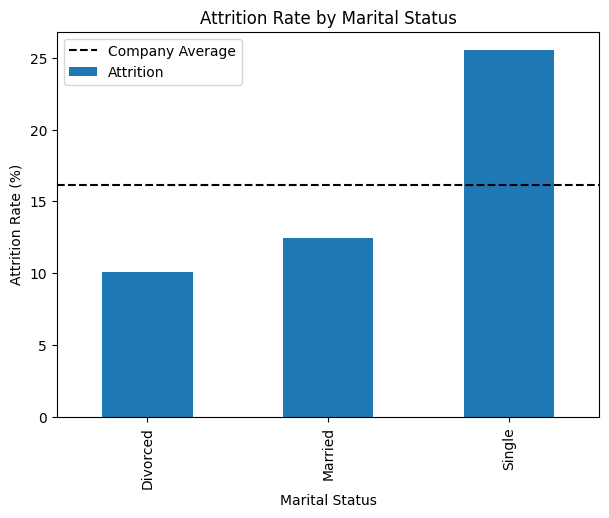

In [55]:
plt.figure(figsize=(7,5))
marital_result.plot(kind="bar")
plt.axhline(overall, linestyle="--",color='black' ,label="Company Average")
plt.title("Attrition Rate by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Attrition Rate (%)")
plt.legend()
plt.show()

**Insight:**
Single employees had the highest attrition rate (25.5%), more than double that of divorced employees (10.1%), making marital status an important demographic factor.

- ## Distance

In [56]:
# Distance from Home Categories
bins = [0, 5, 15, float("inf")]
labels = ["Near (0-5)", "Moderate (6-15)", "Far (15+)"]
df["DistanceCategory"] = pd.cut(df["DistanceFromHome"],bins=bins,labels=labels)
df["DistanceCategory"]

0            Near (0-5)
1       Moderate (6-15)
2            Near (0-5)
3            Near (0-5)
4            Near (0-5)
             ...       
1465          Far (15+)
1466    Moderate (6-15)
1467         Near (0-5)
1468         Near (0-5)
1469    Moderate (6-15)
Name: DistanceCategory, Length: 1470, dtype: category
Categories (3, object): ['Near (0-5)' < 'Moderate (6-15)' < 'Far (15+)']

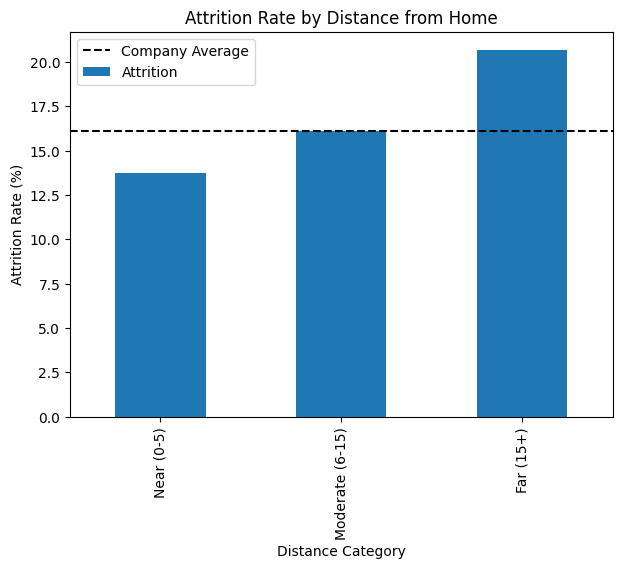

In [57]:
# Attrition Rate by Distance
distance_attrition = df.groupby("DistanceCategory", observed=False)["Attrition"].mean() * 100
plt.figure(figsize=(7,5))
distance_attrition.plot(kind="bar")
plt.axhline(overall, linestyle="--", color='black',label="Company Average")
plt.title("Attrition Rate by Distance from Home")
plt.xlabel("Distance Category")
plt.ylabel("Attrition Rate (%)")
plt.legend()
plt.show()

**Insight:**
Attrition increased with commuting distance, reaching 20.7% for employees living more than 15 km from work, compared with 13.8% for those living within 5 km.

## 6.  Employee Satisfaction Risk Score
**Business Question:** Which satisfaction dimension most strongly predicts attrition?  
**Why it matters:** Satisfaction drops BEFORE an employee decides to leave — it's a leading indicator.
### Conclusion
- Employees with the lowest Job Satisfaction (rating 1) recorded the highest attrition rate at 22.8%, while employees with the highest satisfaction (rating 4) had the lowest attrition rate of 11.3%, showing that job satisfaction has a strong impact on retention.
- Environment Satisfaction had the strongest relationship with attrition among the three satisfaction dimensions. Employees with the lowest rating had a 25.4% attrition rate, which dropped to around 13–15% as satisfaction improved.
- Employees who left had a lower average Satisfaction Score (2.51) than those who stayed (2.76), indicating that declining satisfaction is associated with a higher likelihood of resignation.
- A high-risk group of 39 employees, identified by overtime, low job satisfaction, and no recent promotion, showed a 33.3% attrition rate—more than double the company average of 16.1%. This makes employee satisfaction a valuable early warning signal for identifying employees at risk of leaving.

In [58]:
# Job Satisfaction
job_sat = df.groupby("JobSatisfaction")["Attrition"].mean() * 100
print("Attrition Rate by Job Satisfaction")
print(job_sat)

Attrition Rate by Job Satisfaction
JobSatisfaction
1    22.837370
2    16.428571
3    16.515837
4    11.328976
Name: Attrition, dtype: float64


In [59]:
# Environment Satisfaction
env_sat = df.groupby("EnvironmentSatisfaction")["Attrition"].mean() * 100
print("\nAttrition Rate by Environment Satisfaction")
print(env_sat)


Attrition Rate by Environment Satisfaction
EnvironmentSatisfaction
1    25.352113
2    14.982578
3    13.686534
4    13.452915
Name: Attrition, dtype: float64


In [60]:
# Relationship Satisfaction
rel_sat = df.groupby("RelationshipSatisfaction")["Attrition"].mean() * 100
print("\nAttrition Rate by Relationship Satisfaction")
print(rel_sat)


Attrition Rate by Relationship Satisfaction
RelationshipSatisfaction
1    20.652174
2    14.851485
3    15.468410
4    14.814815
Name: Attrition, dtype: float64


In [61]:
# Composite Satisfaction Risk Score
df['SatisfactionScore'] = df[['JobSatisfaction','EnvironmentSatisfaction','RelationshipSatisfaction']].mean(axis=1).round(2)
score_comparison = df.groupby('Attrition')['SatisfactionScore'].agg(['mean','median']).reset_index()
score_comparison['Attrition'] = score_comparison['Attrition'].map({0: 'Stayed', 1: 'Left'})
score_comparison.columns = ['Group', 'Mean Score', 'Median Score']
print(score_comparison.round(3))

    Group  Mean Score  Median Score
0  Stayed       2.761          2.67
1    Left       2.511          2.67


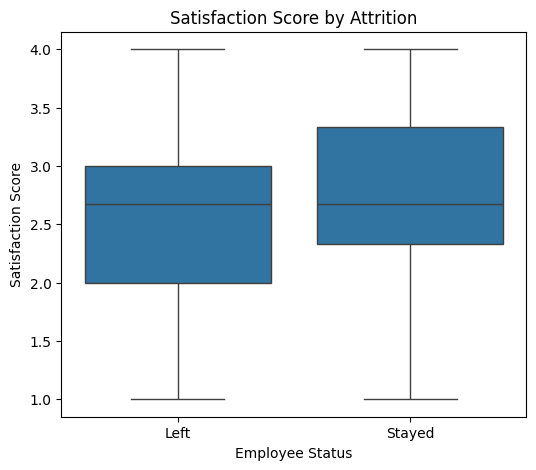

In [62]:
# Satisfaction Score by Employee Status
df["Status"] = df["Attrition"].map({0: "Stayed", 1: "Left"})
plt.figure(figsize=(6,5))
sns.boxplot(data=df,x="Status",y="SatisfactionScore")
plt.title("Satisfaction Score by Attrition")
plt.xlabel("Employee Status")
plt.ylabel("Satisfaction Score")
plt.show()

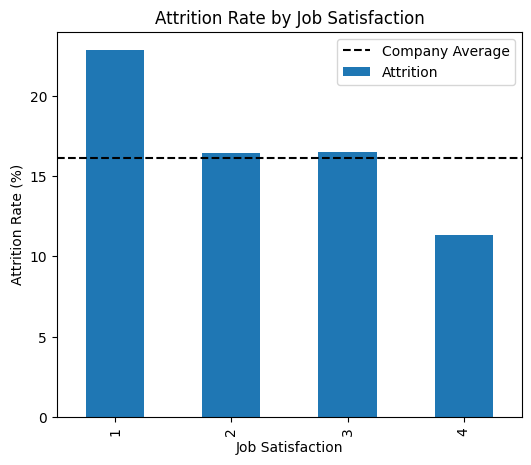

In [63]:
# Attrition Rate by Job Satisfaction
sat_attrition = df.groupby("JobSatisfaction")["Attrition"].mean() * 100
plt.figure(figsize=(6,5))
sat_attrition.plot(kind="bar")
plt.axhline(overall, linestyle="--",color='black' ,label="Company Average")
plt.title("Attrition Rate by Job Satisfaction")
plt.xlabel("Job Satisfaction")
plt.ylabel("Attrition Rate (%)")
plt.legend()
plt.show()

In [64]:
df["IsHighRisk"] = ((df["OverTime"] == "Yes") &(df["JobSatisfaction"] <= 2) &(df["YearsSinceLastPromotion"] >= 3))

In [65]:
print("High-Risk Employees:", df["IsHighRisk"].sum())
high_risk_rate = df[df["IsHighRisk"]]["Attrition"].mean() * 100
print("High-Risk Attrition Rate:", round(high_risk_rate, 2), "%")
print("Company Attrition Rate:", round(overall, 2), "%")

High-Risk Employees: 39
High-Risk Attrition Rate: 33.33 %
Company Attrition Rate: 16.12 %


## HR Executive Summary

### 1. Overall Attrition Rate

IBM's overall attrition rate is **16.1%**, with **237 out of 1,470 employees** leaving the organization. This serves as the baseline for identifying high-risk employee groups throughout the analysis.

### 2. Attrition by Department & Job Role

Employee turnover is highest in the **Sales department (20.6%)**, followed by **Human Resources (19.0%)**. At the job-role level, **Sales Representatives (39.8%)** face the greatest attrition risk, making sales-related roles the highest priority for retention initiatives.

### 3. Tenure of Attrited vs Retained Employees

Employees are most likely to leave during the early stages of their careers. The **0–2 year tenure group** has the highest attrition rate (**29.8%**), and employees who left had a much shorter median tenure than those who stayed, highlighting the importance of strengthening onboarding and early-career support.

### 4. Compensation Gap Index

Employees who left earned a median monthly income of **₹3,202**, compared with **₹5,204** for employees who stayed, creating a **₹2,002 monthly salary gap**. Low-income employees experienced the highest attrition, suggesting that competitive compensation, timely promotions, and clear career growth opportunities are important retention drivers.

### 5. Overtime & Work-Life Balance Impact

Employees working overtime recorded an attrition rate of **30.5%**, nearly double the company average of **16.1%**, making overtime the strongest behavioral predictor of employee turnover. Poor work-life balance further increases the likelihood of attrition, emphasizing the need for healthier workload management.

### 6. Employee Satisfaction Risk Score

Employees with low job, environment, and relationship satisfaction consistently showed higher attrition. A high-risk group identified by **overtime, low job satisfaction, and no promotion for at least three years** recorded a **33.3% attrition rate**, demonstrating that satisfaction metrics can be used as an effective early warning system for employee turnover.

Overall, the analysis indicates that IBM should focus on **retaining early-career employees, reducing overtime, improving compensation and promotion practices, strengthening employee satisfaction, and implementing targeted retention strategies for Sales and other high-risk roles** to reduce future attrition.


### Exporting Final Dashboard Dataset for Power BI

In [66]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeNumber',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Status',
       'TenureBracket', 'IncomePerYear', 'IncomeCategory',
       'SalaryGrowthPotential', 'AgeGroup', 'DistanceCategory',
       'SatisfactionScore', 'IsHighRisk'],
      dtype='object')

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 41 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   Age                       1470 non-null   int64   
 1   Attrition                 1470 non-null   int64   
 2   BusinessTravel            1470 non-null   object  
 3   DailyRate                 1470 non-null   int64   
 4   Department                1470 non-null   object  
 5   DistanceFromHome          1470 non-null   int64   
 6   Education                 1470 non-null   int64   
 7   EducationField            1470 non-null   object  
 8   EmployeeNumber            1470 non-null   int64   
 9   EnvironmentSatisfaction   1470 non-null   int64   
 10  Gender                    1470 non-null   object  
 11  HourlyRate                1470 non-null   int64   
 12  JobInvolvement            1470 non-null   int64   
 13  JobLevel                  1470 non-null   int64 

In [68]:
df.to_csv("IBM_HR_Cleaned.csv", index=False)